h = 0.010   avg error = 0.368561  local error @ x≈15: 0.040935  max|1+hλ| = 1.0200  unstable pts: 50.0%  
h = 0.050   avg error = 1.258792  local error @ x≈15: 0.152506  max|1+hλ| = 1.1000  unstable pts: 49.7%  
h = 0.150   avg error = 1.950547  local error @ x≈15: 0.251454  max|1+hλ| = 1.3000  unstable pts: 49.3%  
h = 0.200   avg error = 2.059003  local error @ x≈15: 0.264472  max|1+hλ| = 1.4000  unstable pts: 49.1%  
h = 0.250   avg error = 2.130091  local error @ x≈15: 0.269713  max|1+hλ| = 1.5000  unstable pts: 49.6%  
h = 0.300   avg error = 2.172528  local error @ x≈15: 0.271622  max|1+hλ| = 1.5983  unstable pts: 47.2%  
h = 0.350   avg error = 2.200846  local error @ x≈15: 0.294172  max|1+hλ| = 1.7000  unstable pts: 49.5%  
h = 0.400   avg error = 2.214620  local error @ x≈15: 0.206679  max|1+hλ| = 1.8000  unstable pts: 48.8%  
h = 0.450   avg error = 2.232445  local error @ x≈15: 0.220242  max|1+hλ| = 1.9000  unstable pts: 49.3%  
h = 0.500   avg error = 2.239393  local error 

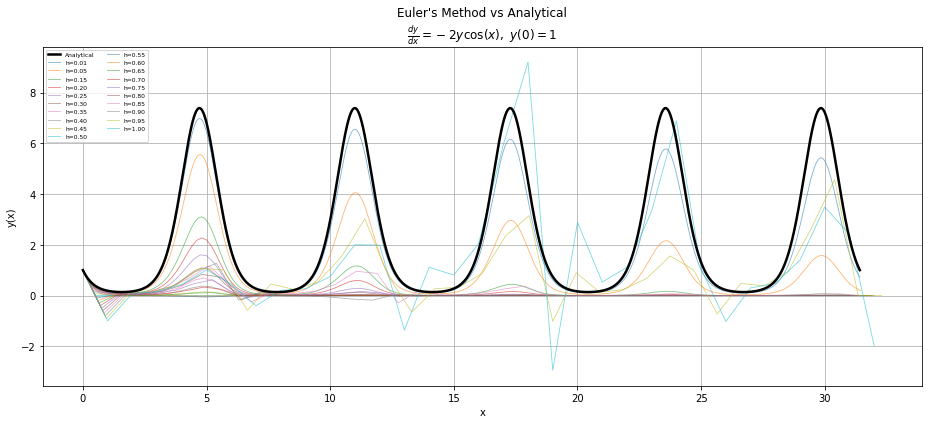

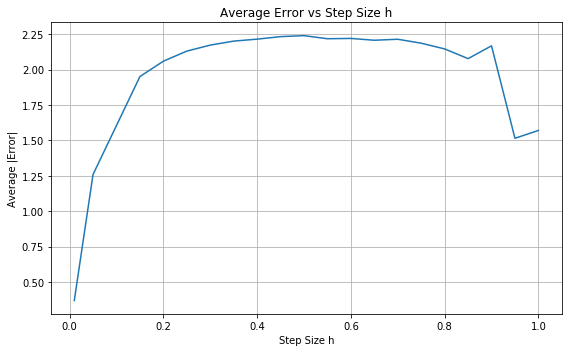

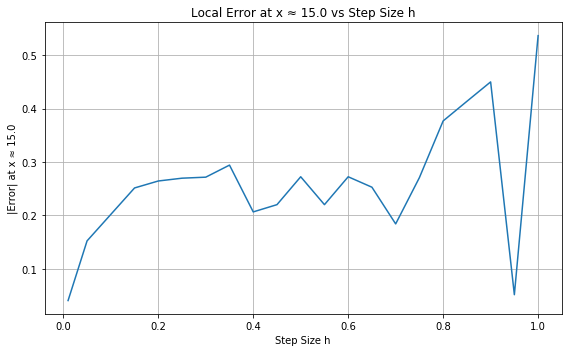

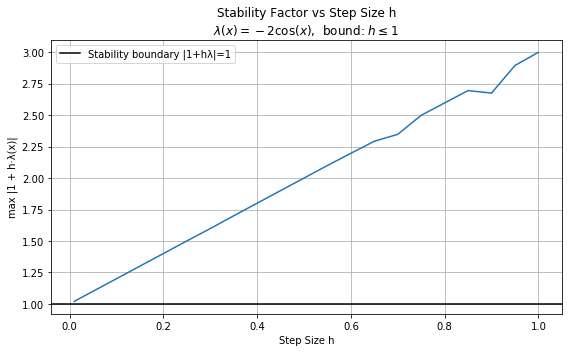

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return -2 * y * np.cos(x)

def analytical(x):
    return np.exp(-2 * np.sin(x))

x_start, x_end = 0, 10 * np.pi
step_sizes = [0.01, 0.05] + list(np.round(np.arange(0.15, 1.01, 0.05), 10))
x_target = 15.0

avg_errors   = []
local_errors = []
hs_used      = []
max_eig_mags = []

plt.figure(1, figsize=(13, 6))
x_exact = np.linspace(x_start, x_end, 10000)
y_exact = analytical(x_exact)
plt.plot(x_exact, y_exact, 'k-', linewidth=2.5, label='Analytical', zorder=5)

for h in step_sizes:
    x_values = np.arange(x_start, x_end + h, h)
    y_values = np.zeros(len(x_values))
    y_values[0] = 1.0

    blown = False
    for i in range(1, len(x_values)):
        y_new = y_values[i-1] + h * f(x_values[i-1], y_values[i-1])
        if not np.isfinite(y_new) or abs(y_new) > 1e10:
            blown = True
            x_values = x_values[:i]
            y_values = y_values[:i]
            break
        y_values[i] = y_new

    y_analytical_at_x = analytical(x_values)
    errors = np.abs(y_values - y_analytical_at_x)
    avg_err = np.mean(errors)

    idx = np.argmin(np.abs(x_values - x_target))
    x_close = x_values[idx]
    y_euler_15 = y_values[idx]
    y_exact_15 = analytical(x_close)
    local_err = abs(y_euler_15 - y_exact_15)

    # stability: λ(x) = -2cos(x), worst case |1 + h*λ|
    lam_x    = -2 * np.cos(x_values)
    eig_mags = np.abs(1 + h * lam_x)
    max_mag  = np.max(eig_mags)
    pct_unstable = np.mean(eig_mags > 1.0) * 100

    status = "BLEW UP" if blown else f"avg err={avg_err:.5f}"
    print(f"h = {h:<6.3f}  avg error = {avg_err:.6f}  "
          f"local error @ x≈15: {local_err:.6f}  "
          f"max|1+hλ| = {max_mag:.4f}  unstable pts: {pct_unstable:.1f}%"
          f"  {'-> BLEW UP' if blown else ''}")

    avg_errors.append(avg_err)
    local_errors.append(local_err)
    hs_used.append(h)
    max_eig_mags.append(max_mag)

    plt.plot(x_values, y_values, alpha=0.6, linewidth=0.8, label=f'h={h:.2f}')

plt.xlabel('x')
plt.ylabel('y(x)')
plt.title("Euler's Method vs Analytical\n"
          r"$\frac{dy}{dx} = -2y\cos(x),\ y(0)=1$")
plt.legend(fontsize=6, ncol=2)
plt.grid(True)
plt.tight_layout()

# Plot 2: average error vs h
plt.figure(2, figsize=(8, 5))
plt.plot(hs_used, avg_errors)
plt.xlabel('Step Size h')
plt.ylabel('Average |Error|')
plt.title('Average Error vs Step Size h')
plt.grid(True)
plt.tight_layout()

# Plot 3: local error at x ≈ 15 vs h
plt.figure(3, figsize=(8, 5))
plt.plot(hs_used, local_errors)
plt.xlabel('Step Size h')
plt.ylabel(f'|Error| at x ≈ {x_target}')
plt.title(f'Local Error at x ≈ {x_target} vs Step Size h')
plt.grid(True)
plt.tight_layout()

# Plot 4: max local eigenvalue magnitude vs h
plt.figure(4, figsize=(8, 5))
plt.plot(hs_used, max_eig_mags)
plt.axhline(1.0, color='black', label='Stability boundary |1+hλ|=1')
plt.xlabel('Step Size h')
plt.ylabel('max |1 + h·λ(x)|')
plt.title('Stability Factor vs Step Size h\n'
          r'$\lambda(x) = -2\cos(x)$,  bound: $h \leq 1$')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()